# Initial Setup

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf




In [4]:
spark = (
    SparkSession.builder
    .appName("HOPE_Data_Merging_EDA")
    .master("local[*]")
    .getOrCreate()  
)

spark.sparkContext.setLogLevel("WARN")

print("spark version: ", spark.version)

spark version:  3.5.1


#  Load clean dataset (from HDFS)

In [5]:
hoep_df = spark.read.parquet("hdfs://localhost:9000/hoep_project/interim/hoep_clean.parquet")

demand_df = spark.read.parquet("hdfs://localhost:9000/hoep_project/interim/demand_clean.parquet")

generation_df = spark.read.parquet("hdfs://localhost:9000/hoep_project/interim/generation_clean.parquet")

# Inspect datasets

In [6]:
print("HOEP rows:", hoep_df.count())
print("Demand rows:", demand_df.count())
print("Generation rows:", generation_df.count(),"\n")

print("HOEP schema:")
hoep_df.printSchema()

print("Demand schema:")
demand_df.printSchema()

print("Generation schema:")
generation_df.printSchema()


HOEP rows: 20424
Demand rows: 20424
Generation rows: 20424 

HOEP schema:
root
 |-- date: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- hoep: double (nullable = true)
 |-- hour_1_predispatch: double (nullable = true)
 |-- hour_2_predispatch: double (nullable = true)
 |-- hour_3_predispatch: double (nullable = true)
 |-- market_key: string (nullable = true)

Demand schema:
root
 |-- date: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- market_demand: double (nullable = true)
 |-- ontario_demand: double (nullable = true)
 |-- market_key: string (nullable = true)

Generation schema:
root
 |-- date: string (nullable = true)
 |-- hour: integer (nullable = true)
 |-- nuclear: double (nullable = true)
 |-- gas: double (nullable = true)
 |-- hydro: double (nullable = true)
 |-- wind: double (nullable = true)
 |-- solar: double (nullable = true)
 |-- biofuel: double (nullable = true)
 |-- other: string (nullable = true)
 |-- total_output: integer (nullabl

# Merge Datasets (Full Outer Join) and Check for Anomalies

A full outer join is used to prevent silent row dropping when date and hour do not align between datasets.

In [7]:
merge_df = (
    hoep_df
    .join(demand_df,["date","hour","market_key"],"full")
    .join(generation_df,["date","hour","market_key"],"full")
    .orderBy("date","hour")
)


# Add Time Features


In [8]:
merge_df = ( merge_df
    .withColumn('month',      F.month('date'))
    .withColumn('day_of_week',  F.dayofweek('date'))  # PySpark: 1=Sun
    .withColumn('year',       F.year('date')) 
    .withColumn('is_weekend', (F.dayofweek('date').isin([1, 7])).cast('int')) 
    .withColumn('season',     F.when(F.month('date').isin([12,1,2]),  0)  # Winter
                                  .when(F.month('date').isin([3,4,5]),   1)  # Spring
                                  .when(F.month('date').isin([6,7,8]),   2)  # Summer
                                  .otherwise(3)) )

# Data Quality Check

In [9]:
# Count after full join (to make sure match with datasets )
print("Merged dataset raws:", merge_df.count())
merge_df.show(10)

# Check duplicates
print("merged dataset check for duplicate rows: ")
merge_df.groupBy("date","hour").count().filter(F.col("count")>1).show()

# Check missing values
print("checking merged dataset missing values:")
merge_df.select(
    [
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in merge_df.columns
    ]
).show()

Merged dataset raws: 20424
+----------+----+--------------+-----+------------------+------------------+------------------+-------------+--------------+-------+------+------+-----+-----+-------+-----+------------+-----+-----------+----+----------+------+
|      date|hour|    market_key| hoep|hour_1_predispatch|hour_2_predispatch|hour_3_predispatch|market_demand|ontario_demand|nuclear|   gas| hydro| wind|solar|biofuel|other|total_output|month|day_of_week|year|is_weekend|season|
+----------+----+--------------+-----+------------------+------------------+------------------+-------------+--------------+-------+------+------+-----+-----+-------+-----+------------+-----+-----------+----+----------+------+
|2023-01-01|   1|2023-01-01_H01|14.42|             41.03|              43.0|             39.59|      15130.0|       13514.0| 9977.0| 130.0|4185.0|533.0|  0.0|   19.0| NULL|       14844|    1|          1|2023|         1|     0|
|2023-01-01|   2|2023-01-01_H02|19.21|             47.23|        

# Convert to Pandas for Analysis and Visualization

In [10]:
pdf = merge_df.toPandas()
pdf["date"] = pd.to_datetime(pdf["date"])
pdf = pdf.sort_values(["date", "hour"]).reset_index(drop=True)
pdf["time_index"] = range(len(pdf))




# Target Variable Analysis — HOEP Price

## 1. Price distributuion

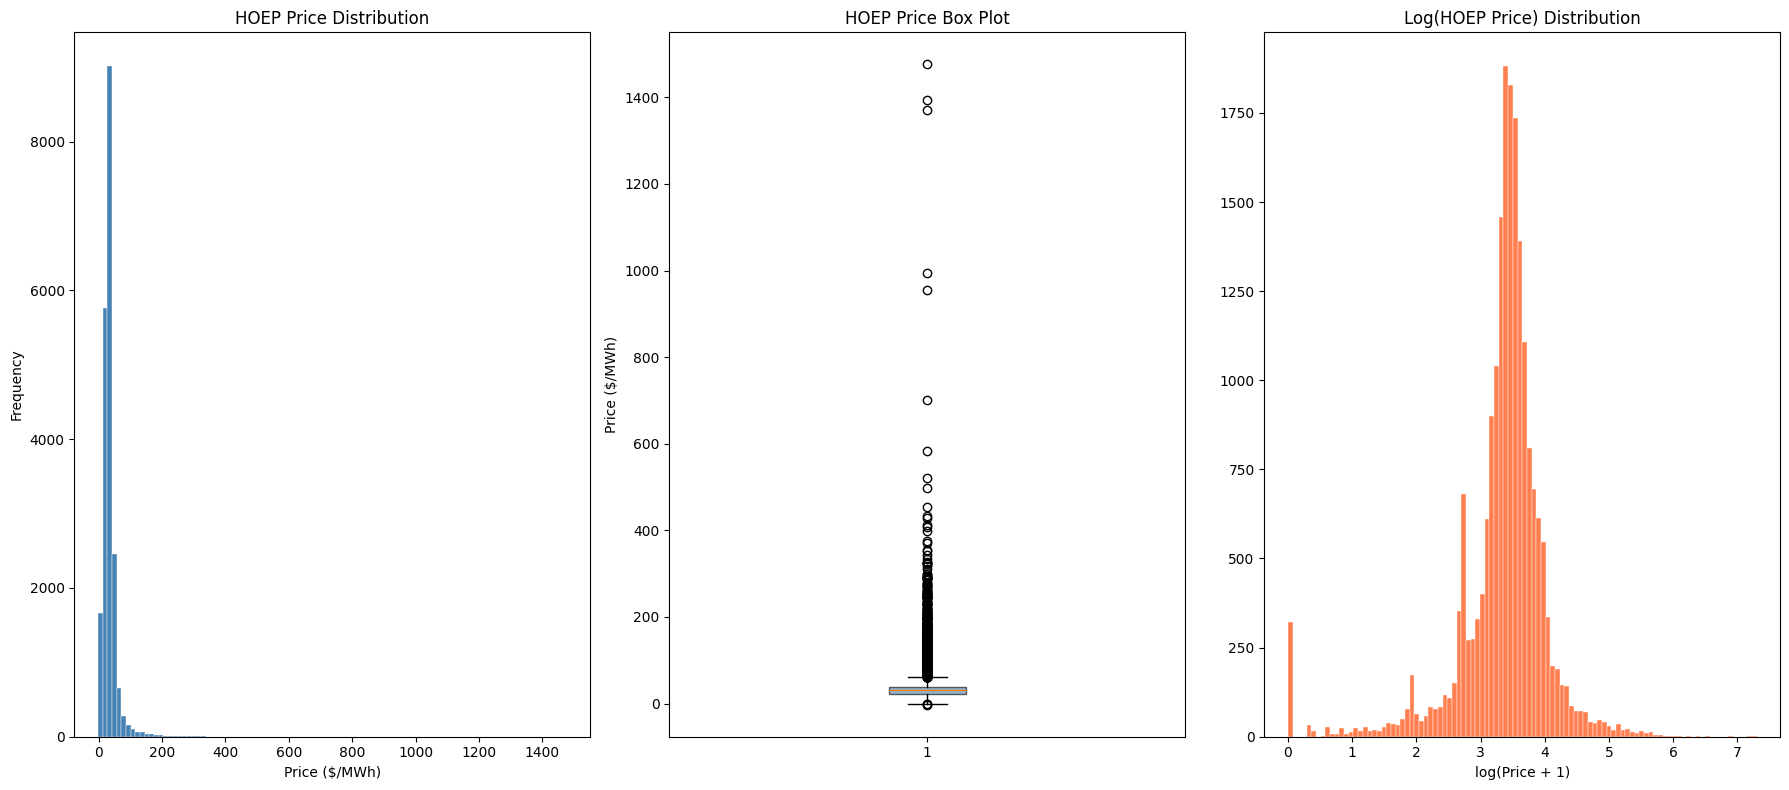

Skewness:  16.0738
Kurtosis:  528.6133
Negative prices: 6
Zero prices:     314


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Histogram
axes[0].hist(pdf['hoep'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('HOEP Price Distribution')
axes[0].set_xlabel('Price ($/MWh)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(pdf['hoep'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('HOEP Price Box Plot')
axes[1].set_ylabel('Price ($/MWh)')

# Log-transformed distribution (handles skewness)
log_price = np.log1p(pdf['hoep'].clip(lower=0))
axes[2].hist(log_price, bins=100, color='coral', edgecolor='white', linewidth=0.3)
axes[2].set_title('Log(HOEP Price) Distribution')
axes[2].set_xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

print(f'Skewness:  {pdf["hoep"].skew():.4f}')
print(f'Kurtosis:  {pdf["hoep"].kurt():.4f}')
print(f'Negative prices: {(pdf["hoep"] < 0).sum()}')
print(f'Zero prices:     {(pdf["hoep"] == 0).sum()}')

We examine the distribution of HOEP price from three angles:

- **Histogram** — reveals the overall shape of the distribution,
including skewness and the presence of extreme price spikes.

- **Box plot** — identifies outliers and quantifies price volatility
through the interquartile range (IQR).

- **Log-transformed distribution** — assesses whether a log
transformation normalizes the distribution, which directly informs
the target variable preprocessing strategy before modeling.

Together, these three plots answer a critical preprocessing question:
*Should HOEP price be transformed before being fed into VAR,
XGBoost, and LSTM models?* Models such as VAR assume normally
distributed residuals, while LSTM and XGBoost can be sensitive to
extreme values — making this analysis an essential first step before
model development.

## 2 .Price Spike Analysis

99th percentile threshold: $147.27/MWh
Price spikes (>p99):        205 hours (1.00%)
Negative prices:            6 hours (0.03%)
Max price:                  $1476.34/MWh
Min price:                  $-2.76/MWh


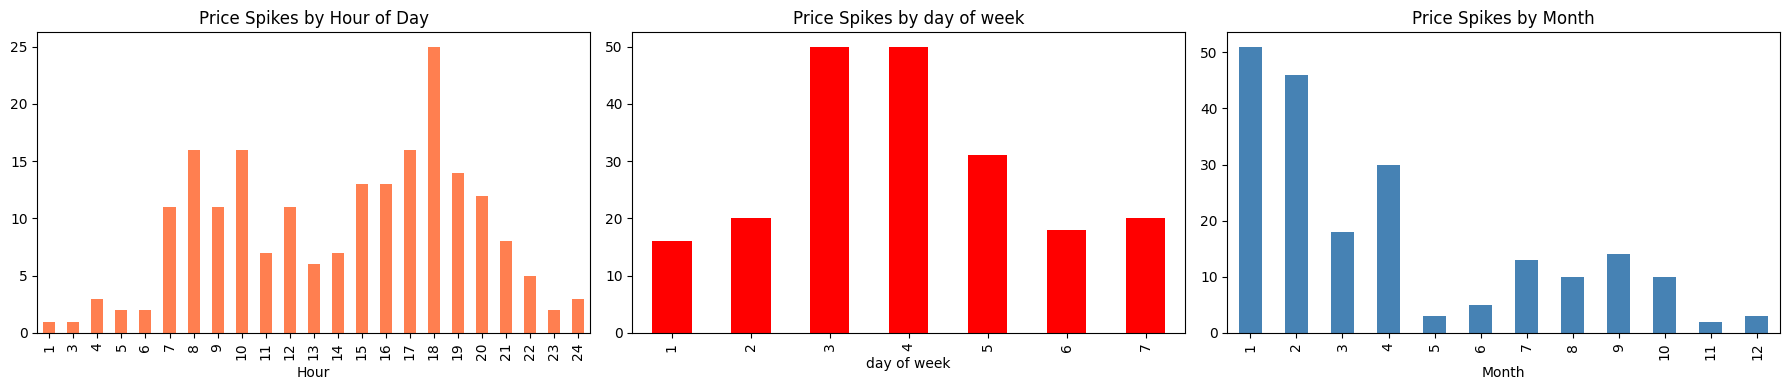

In [12]:
p99 = pdf['hoep'].quantile(0.99)
p01 = pdf['hoep'].quantile(0.01)

spikes   = pdf[pdf['hoep'] > p99]
negatives= pdf[pdf['hoep'] < 0]

print(f'99th percentile threshold: ${p99:.2f}/MWh')
print(f'Price spikes (>p99):        {len(spikes)} hours ({len(spikes)/len(pdf)*100:.2f}%)')
print(f'Negative prices:            {len(negatives)} hours ({len(negatives)/len(pdf)*100:.2f}%)')
print(f'Max price:                  ${pdf['hoep'].max():.2f}/MWh')
print(f'Min price:                  ${pdf['hoep'].min():.2f}/MWh')

# When do spikes occur?
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
spikes.groupby('hour').size().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Price Spikes by Hour of Day')
axes[0].set_xlabel('Hour')


spikes.groupby('day_of_week').size().plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('Price Spikes by day of week') # dayofweek convention: 1=Sun, 2=Mon, 3=Tue, 4=Wed, 5=Thu, 6=Fri, 7=Sat
axes[1].set_xlabel('day of week')


spikes.groupby('month').size().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Price Spikes by Month')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

## Finding: Price Spikes Are Temporally Structured

Spike analysis reveals that extreme HOEP prices are not random events
but follow clear temporal patterns:

- **Hourly:** Spikes peak at hour 19 (7 PM), corresponding to
  evening residential demand surges.
- **Daily:** Mid-week days (Tue-Wed) show 2.5× more spikes than
  weekends, reflecting industrial and commercial demand patterns.
- **Monthly:** January and February dominate spike occurrence,
  indicating a winter-driven stress pattern unique to Ontario's
  heating-intensive climate.

These findings justify the inclusion of `hour`, `dayofweek`, and
`month` as primary features across all models

# Time Series Analysis 

1. HOEP Time Series

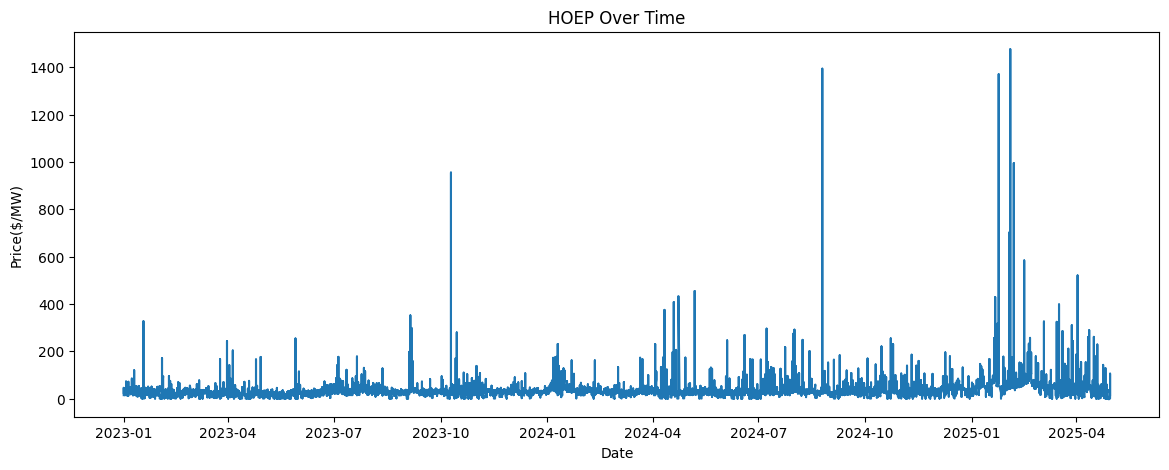

In [13]:
plt.figure(figsize=(14,5))
plt.plot(pdf["date"], pdf["hoep"])
plt.title("HOEP Over Time")
plt.xlabel("Date")
plt.ylabel("Price($/MW)")
plt.show()

2. One Week Zoom (In 2024)

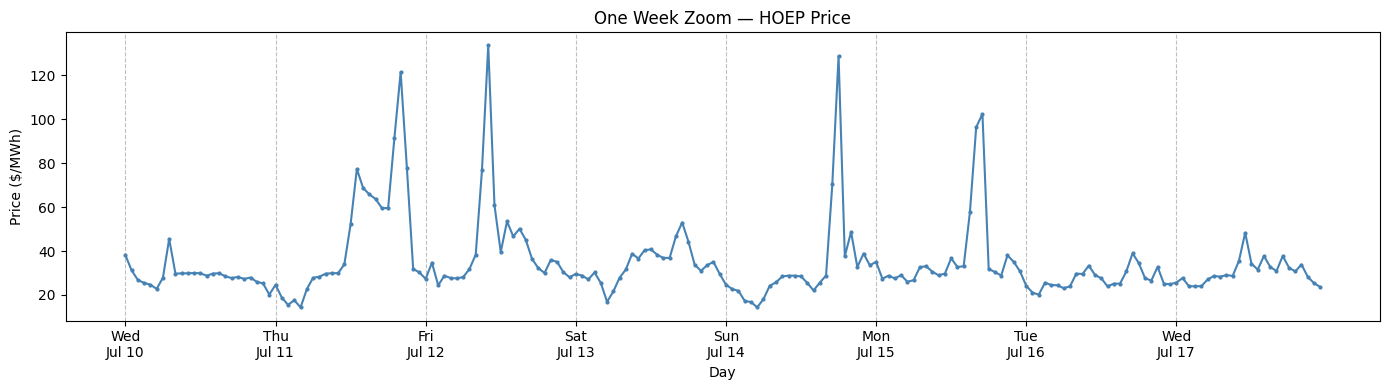

In [14]:
week = pdf[(pdf['date'] >= '2024-07-10') & (pdf['date'] <= '2024-07-17')]

plt.figure(figsize=(14, 4))
plt.plot(range(len(week)), week['hoep'].values,
         color='steelblue', marker='o', markersize=2)

# Add vertical lines between days
for i in range(0, len(week), 24):
    plt.axvline(x=i, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

#Label each day at midnight (every 24 rows)
day_labels = week['date'].dt.strftime('%a\n%b %d').unique()
plt.xticks(
    ticks=range(0, len(week), 24),
    labels=day_labels
)

plt.title('One Week Zoom — HOEP Price')
plt.ylabel('Price ($/MWh)')
plt.xlabel('Day')
plt.tight_layout()
plt.show()


# Pearson Correlation Coefficient Heatmap

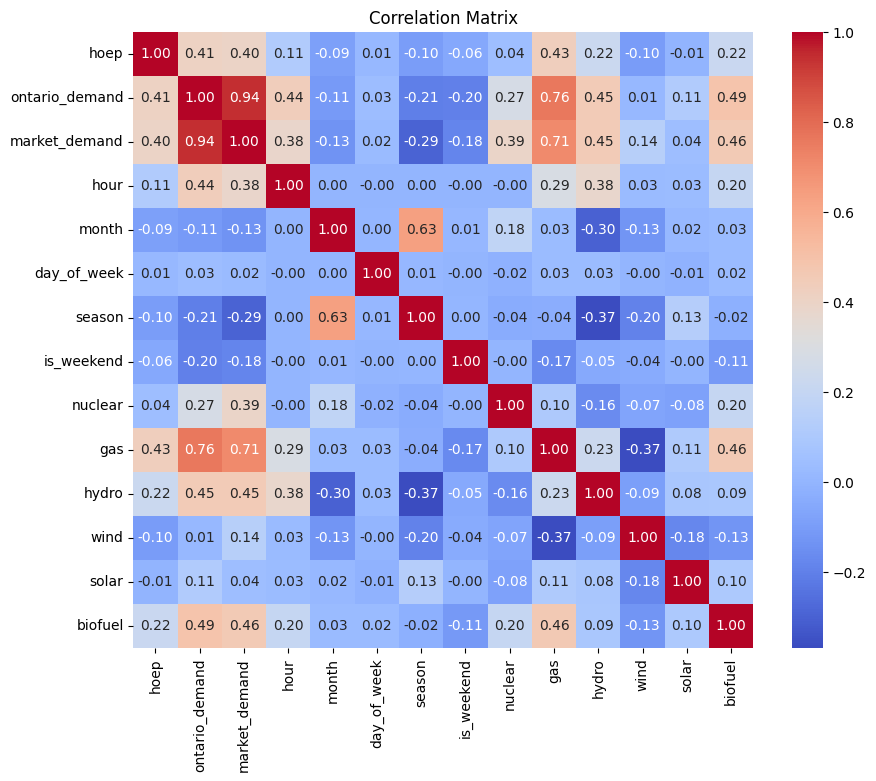

In [15]:
corr_cols = ['hoep', 'ontario_demand', 'market_demand', 
             'hour', 'month', 'day_of_week','season', 'is_weekend',
             'nuclear', 'gas', 'hydro', 'wind', 'solar', 'biofuel',]

plt.figure(figsize=(10,8))
sns.heatmap(pdf[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Pearson Correlation Coefficient (PCC) is one of the simplest and 
most widely used methods for feature selection in the electricity 
price forecasting literature. It measures the strength and direction 
of the **linear relationship** between two variables, providing a 
data-driven basis for dimensionality reduction by identifying and 
removing redundant or weakly related features before modeling.

The PCC between two variables X and Y is defined as:

$$r = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}
{\sqrt{\sum_{i=1}^{n}(X_i - \bar{X})^2 \cdot 
\sum_{i=1}^{n}(Y_i - \bar{Y})^2}}$$

Where:
- $X_i$, $Y_i$ are individual observations
- $\bar{X}$, $\bar{Y}$ are the means of X and Y
- $r \in [-1, 1]$

The result is interpreted as follows:

| Value | Interpretation |
|---|---|
| $r = 1$ | Perfect positive linear relationship |
| $r = -1$ | Perfect negative linear relationship |
| $r = 0$ | No linear relationship |
| $\|r\| > 0.7$ | Strong correlation |
| $0.3 < \|r\| < 0.7$ | Moderate correlation |
| $\|r\| < 0.3$ | Weak correlation — candidate for removal |

# Autocorrelation Analysis


1. ACF Plot

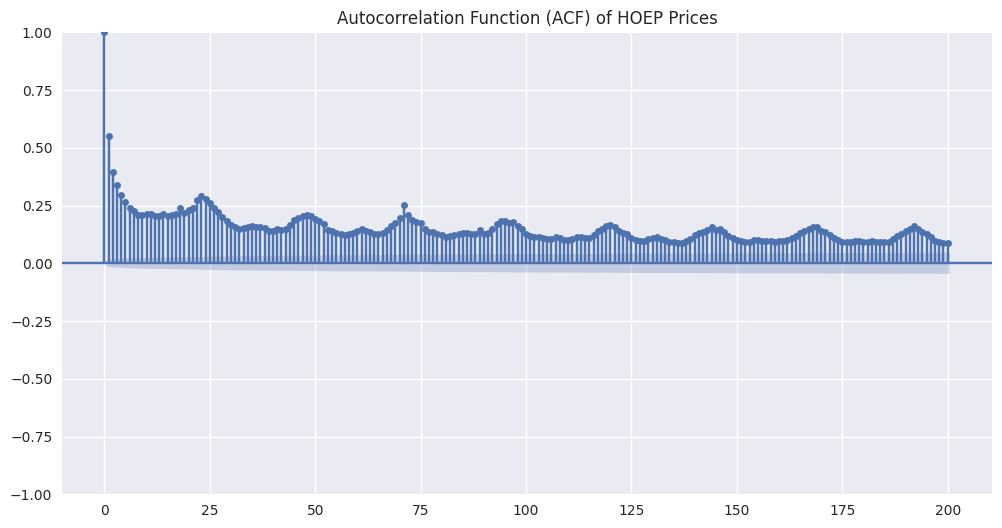

In [23]:
series = pdf["hoep"]

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(series, lags=200, ax=ax, alpha=0.05)
ax.set_title('Autocorrelation Function (ACF) of HOEP Prices')
ax.grid(True, alpha=1)
plt.show()

2. PACF Plot

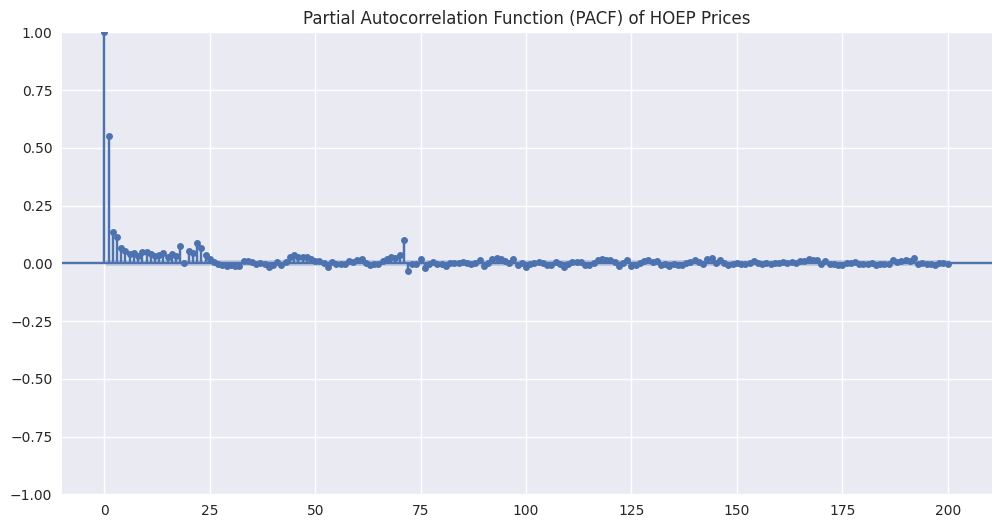

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(series, lags=200, ax=ax, alpha=0.05)
ax.set_title('Partial Autocorrelation Function (PACF) of HOEP Prices')
ax.grid(True, alpha=1)
plt.show()

### ACF and PACF Analysis

The ACF plot reveals three key characteristics of HOEP prices:

1. **Strong short-term momentum** — ACF decays gradually from
   ρ(1)≈0.55, confirming that recent prices are strong predictors
   of the next hour.

2. **Daily seasonality** — A scalloped pattern with bumps recurring
   every 24 lags confirms the presence of a daily price cycle,
   mathematically validating `hour` and `lag_24` as features.

3. **Long memory** — ACF remains positive beyond lag 200,
   suggesting persistent price dependencies.

The PACF plot reveals a sharp cutoff after lag 3-5, identifying
an AR(3-4) process — meaning only the last 3-4 hours have DIRECT
effects on current price. A small but significant spike at lag 24
confirms that the daily cycle has an independent direct effect
beyond the short-term AR component.

**Modeling implications:**
- VAR order: p = 3 or 4 (confirmed by PACF cutoff)
- Key lag features for XGBoost: lag_1, lag_2, lag_3, lag_24
- LSTM sequence window: 24-48 hours minimum
- Stationarity to be confirmed by ADF test

# Save Master Dataset

In [15]:
spark_df = spark.createDataFrame(pdf)

spark_df.write.mode("overwrite").parquet(
    "../data/processed/master_dataset.parquet"
)

26/03/15 21:06:18 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


26/03/15 22:05:58 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 2241122 ms exceeds timeout 120000 ms
26/03/15 22:05:58 WARN SparkContext: Killing executors is not supported by current scheduler.
26/03/15 22:06:07 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$